In [ ]:
# Cell 0: Setup
!pip install -q optuna openpyxl

import os, sys, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.samplers import GridSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

REPO = '/content/drive/MyDrive/imbalanced-data-LWCE'
DATA_PATH = '/content/drive/MyDrive/imbalanced loss project/data'

# custom_losses.py / experiment_utils.py 는 REPO 루트, data_handler.py 는 tabular_data/src/.
# ⚠️ tabular_data/src/ 에도 동명의 custom_losses.py(XGBoost 레거시판)가 있다.
#    insert(0)은 나중 호출이 앞에 오므로 REPO를 마지막에 넣어 루트 버전이 먼저 잡히게 한다.
sys.path.insert(0, f'{REPO}/tabular_data/src')
sys.path.insert(0, REPO)

from data_handler import load_dataset
from custom_losses import get_clf_loss
from experiment_utils import (GradLogger, extended_metrics, OPTUNA_GRIDS,
                              grid_n_trials, LOSS_CONFIGS_11, ABLATION_ROWS)

RESULTS_DIR = f'{REPO}/tabular_data/results/mlp'
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

# --- 상수 ---
DATASETS = [
    'credit_card_fraud', 'aps_failure', 'bank_marketing', 'telco_churn',
    'german_credit', 'secom', 'credit_card_default',
    'glass', 'steel_faults', 'yeast', 'page_blocks',
]
# 3차 피드백: §4.2 baseline에 logitadj 추가, §4.5 ablation에 combined 추가,
#             eslwce는 논문 proposed 3형제 중 하나라 필수.
LOSS_CONFIGS = LOSS_CONFIGS_11   # 11종: 기존 8 + eslwce/combined/logitadj
SEEDS        = [42, 43, 44, 45, 46]

BATCH_SIZE   = 512
FINAL_EPOCHS = 100   # 소규모 데이터셋 수렴 보장
PROXY_EPOCHS = 20
PROXY_RATIO  = 0.20
# Optuna 그리드는 experiment_utils.OPTUNA_GRIDS로 통일 (1D 30 trials, combined만 2D 60).

print(f'Losses ({len(LOSS_CONFIGS)}): {LOSS_CONFIGS}')
print(f'총 실험 수: {len(DATASETS)} datasets x {len(LOSS_CONFIGS)} losses x {len(SEEDS)} seeds '
      f'= {len(DATASETS)*len(LOSS_CONFIGS)*len(SEEDS)} runs')

In [2]:
# Cell 1: Data loading
raw_data = {}

for ds in DATASETS:
    X_tr, X_te, y_tr, y_te = load_dataset(ds, DATA_PATH, test_size=0.3, random_state=42)

    X_tr = (X_tr.values if hasattr(X_tr, 'values') else X_tr).astype(np.float32)
    X_te = (X_te.values if hasattr(X_te, 'values') else X_te).astype(np.float32)
    y_tr = np.array(y_tr, dtype=np.int64)
    y_te = np.array(y_te, dtype=np.int64)

    # remap labels to 0..C-1 (handles gaps like glass {0,1,2,3,4,6})
    unique = np.unique(y_tr)
    if not np.array_equal(unique, np.arange(len(unique))):
        remap = {v: i for i, v in enumerate(unique)}
        y_tr = np.array([remap[v] for v in y_tr], dtype=np.int64)
        y_te = np.array([remap[v] for v in y_te], dtype=np.int64)

    num_classes  = len(np.unique(y_tr))
    class_counts = [int((y_tr == c).sum()) for c in range(num_classes)]
    ir = max(class_counts) / max(min(class_counts), 1)

    raw_data[ds] = (X_tr, X_te, y_tr, y_te, class_counts, num_classes)
    print(f'{ds:25s}  feat={X_tr.shape[1]:4d}  C={num_classes:2d}  '
          f'train={len(y_tr):6d}  IR={ir:8.1f}')

credit_card_fraud          feat=  29  C= 2  train=199364  IR=   578.5
aps_failure                feat= 170  C= 2  train= 60000  IR=    59.0
bank_marketing             feat=  42  C= 2  train= 31647  IR=     7.5
telco_churn                feat=  30  C= 2  train=  4930  IR=     2.8
german_credit              feat=  48  C= 2  train=   700  IR=     2.3
secom                      feat= 590  C= 2  train=  1096  IR=    14.0
credit_card_default        feat=  33  C= 2  train= 21000  IR=     3.5
glass                      feat=   9  C= 6  train=   149  IR=     8.8
steel_faults               feat=  27  C= 7  train=  1358  IR=    12.4
yeast                      feat=   8  C=10  train=  1038  IR=   108.0
page_blocks                feat=  10  C= 5  train=  3831  IR=   171.9


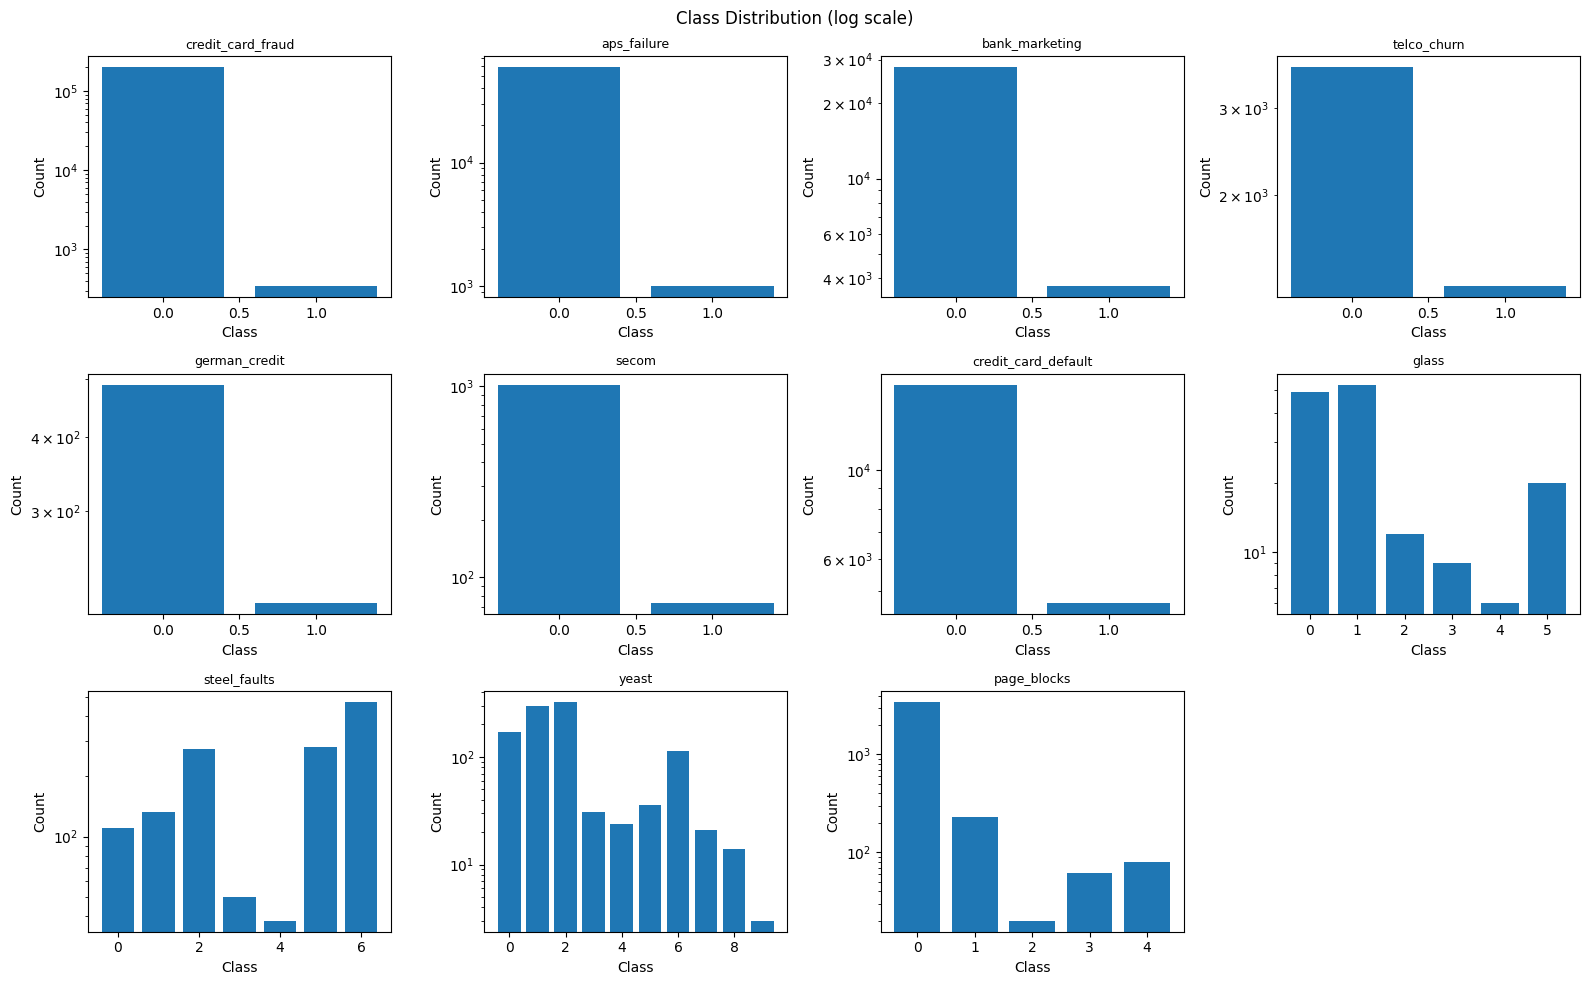

In [3]:
# Cell 2: Class distribution visualization
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, ds in enumerate(DATASETS):
    _, _, _, _, class_counts, _ = raw_data[ds]
    ax = axes[idx]
    ax.bar(range(len(class_counts)), class_counts)
    ax.set_yscale('log')
    ax.set_title(ds, fontsize=9)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')

for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Class Distribution (log scale)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 3: MLP model + metrics

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def compute_metrics(y_true, y_pred, class_counts):
    """
    3차 피드백 §4.3: Macro-F1, Balanced Acc, G-Mean, Minority Recall,
                    Worst-class Acc, Per-class Acc 를 모두 보고.
    기존 Head/Mid/Tail F1(F1 기반)은 유지하고, G-Mean/Worst-class는
    per-class recall 기반으로 별도 계산한다(표준 정의).
    """
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_pc = f1_score(y_true, y_pred, average=None,       zero_division=0).tolist()

    n   = len(class_counts)
    idx = np.argsort(class_counts)  # minority -> majority
    f1a = np.array(f1_pc)

    if n == 2:
        tail_f1 = float(f1a[idx[0]])
        head_f1 = float(f1a[idx[1]])
        mid_f1  = float(f1m)
    else:
        t       = max(1, n // 3)
        tail_f1 = float(f1a[idx[:t]].mean())
        mid_f1  = float(f1a[idx[t:2*t]].mean()) if 2 * t <= n else tail_f1
        head_f1 = float(f1a[idx[2*t:]].mean())  if 2 * t < n  else float(f1a[idx[-t:]].mean())

    out = dict(Accuracy=acc, Balanced_Accuracy=bacc,
               F1_Macro=f1m, F1_Weighted=f1w,
               Per_Class_F1=f1_pc,
               Head_F1=head_f1, Mid_F1=mid_f1, Tail_F1=tail_f1)
    # Per_Class_Acc(=recall) / G_Mean / Worst_Acc — 전 도메인 공용 정의
    out.update(extended_metrics(y_true, y_pred, n))
    return out

In [ ]:
# Cell 4: train_model (definition only — do not execute model here)
# 3차 피드백 §4.7: epoch별 Gradient Norm / Minority·Majority Gradient Ratio 기록.
#   둘 다 학습이 끝나면 복구 불가능 → 반드시 루프 안에서 잡아야 한다.
#   grad clipping을 쓰지 않으므로 GradLogger가 total_grad_norm()으로 측정
#   (clip_grad_norm_과 달리 grad를 수정하지 않아 학습 결과에 영향 없음).

def train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                loss_name, alpha=1.0, gamma=2.0, eps=0.1, tau=1.0, epochs=100, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=min(BATCH_SIZE, len(X_tr)), shuffle=True, num_workers=0)
    te_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
        batch_size=2048, shuffle=False, num_workers=0)

    model     = MLP(X_tr.shape[1], num_classes).to(device)
    criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma,
                             eps=eps, tau=tau).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-5)

    glog = GradLogger(class_counts, num_classes, device)
    history = {'epoch': [], 'train_loss': [],
               'grad_norm': [], 'grad_many': [], 'grad_few': [], 'grad_ratio': []}

    for ep in range(epochs):
        model.train()
        glog.reset()
        run_loss, n_seen = 0.0, 0
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            logits.retain_grad()               # 샘플별 로짓 기울기 관측 (Proposition 4)
            loss = criterion(logits, yb)
            loss.backward()
            glog.update(logits, yb, model)     # optimizer.step() 전에 호출
            optimizer.step()
            run_loss += float(loss) * yb.size(0); n_seen += yb.size(0)
        scheduler.step()

        history['epoch'].append(ep)
        history['train_loss'].append(run_loss / max(1, n_seen))
        for k, v in glog.epoch_end().items():
            history[k].append(v)

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in te_ld:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)

    metrics = compute_metrics(y_te, y_pred, class_counts)
    del model, criterion, optimizer
    gc.collect()
    torch.cuda.empty_cache()
    return metrics, history

In [ ]:
# Cell 5: Optuna search (alpha / gamma / eps / tau)
# 3차 피드백 §3.3: proxy는 train의 stratified 부분집합, 선택 기준은 proxy-val F1-Macro.
#                 test set은 파라미터 선택에 일절 쓰지 않는다.
#            §4.6: study.trials 전체를 저장 → sensitivity 곡선을 추가 학습 없이 확보.
os.environ['TQDM_DISABLE'] = '1'

BP_PATH     = f'{RESULTS_DIR}/_best_params.json'
TRIALS_PATH = f'{RESULTS_DIR}/_optuna_trials.json'

# 디스크에 저장 → Cell 5를 건너뛰고 Cell 6만 돌려도 파라미터가 기본값으로 떨어지지 않는다.
best_params   = json.load(open(BP_PATH))     if os.path.exists(BP_PATH)     else {}
optuna_trials = json.load(open(TRIALS_PATH)) if os.path.exists(TRIALS_PATH) else {}


def proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts, num_classes,
                loss_name, **params):
    torch.manual_seed(42)
    model = MLP(X_ptr.shape[1], num_classes).to(device)
    crit  = get_clf_loss(loss_name, class_counts, **params).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ld    = DataLoader(
        TensorDataset(torch.from_numpy(X_ptr), torch.from_numpy(y_ptr)),
        batch_size=min(BATCH_SIZE, len(X_ptr)), shuffle=True, num_workers=0)
    model.train()
    for _ in range(PROXY_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad()
            crit(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_pval).to(device)).argmax(1).cpu().numpy()
    score = f1_score(y_pval, preds, average='macro', zero_division=0)
    del model, crit, opt
    gc.collect()
    torch.cuda.empty_cache()
    return score


for ds in DATASETS:
    if ds in best_params:
        print(f'Optuna: {ds}  (cached)')
        continue
    X_tr, X_te, y_tr, y_te, class_counts, num_classes = raw_data[ds]
    print(f'\nOptuna: {ds}')

    n_proxy = int(PROXY_RATIO * len(X_tr))
    try:
        proxy_idx, _ = train_test_split(
            np.arange(len(X_tr)), train_size=n_proxy, stratify=y_tr, random_state=42)
    except ValueError:
        proxy_idx = np.random.RandomState(42).choice(len(X_tr), n_proxy, replace=False)
    try:
        ptr_idx, pval_idx = train_test_split(
            proxy_idx, test_size=0.2, stratify=y_tr[proxy_idx], random_state=42)
    except ValueError:
        split = int(0.8 * len(proxy_idx))
        ptr_idx, pval_idx = proxy_idx[:split], proxy_idx[split:]

    X_ptr, y_ptr   = X_tr[ptr_idx],  y_tr[ptr_idx]
    X_pval, y_pval = X_tr[pval_idx], y_tr[pval_idx]

    bp, ts = {}, {}
    for loss_name, grid in OPTUNA_GRIDS.items():
        n_trials = grid_n_trials(grid)          # grid 크기와 정확히 일치해야 함

        def objective(trial, _ln=loss_name, _g=grid):
            params = {p: trial.suggest_float(p, min(vals), max(vals))
                      for p, vals in _g.items()}
            return proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts,
                               num_classes, _ln, **params)

        st = optuna.create_study(direction='maximize', sampler=GridSampler(grid))
        st.optimize(objective, n_trials=n_trials)
        bp[loss_name] = dict(st.best_params)
        # 'if t.value is not None' — 0.0 trial이 필터링되는 버그 방지
        ts[loss_name] = [{'params': t.params, 'value': t.value}
                         for t in st.trials if t.value is not None]
        ps = ', '.join(f'{k}={v:.3f}' for k, v in st.best_params.items())
        print(f'  {loss_name:9s} {ps}  F1={st.best_value:.4f}')

    best_params[ds]   = bp
    optuna_trials[ds] = ts
    json.dump(best_params,   open(BP_PATH, 'w'),     indent=2)
    json.dump(optuna_trials, open(TRIALS_PATH, 'w'), indent=2)

print('\nOptuna search complete.')

In [ ]:
# Cell 6: Full experiments (11 losses x 11 datasets x 5 seeds)
# 결과는 기존 위치에 버전 접미사 없이 저장. 11종 + gradient/per-class/history 포함이라
# 옛 8종 파일과 스키마가 다르므로, Drive의 기존 결과는 미리 정리(보관)한 뒤 실행할 것.
all_results = []
CKPT_PATH = f'{RESULTS_DIR}/_checkpoint.json'
HIST_PATH = f'{RESULTS_DIR}/_histories.json'
COUNTS_PATH = f'{RESULTS_DIR}/_class_counts.json'   # 분석 셀에서 가중치 재계산용

# Cell 5가 디스크에 저장하므로 여기서 다시 읽는다 (Cell 5 미실행 시 빈 dict → 기본값 경고).
best_params   = json.load(open(BP_PATH)) if os.path.exists(BP_PATH) else {}
all_histories = json.load(open(HIST_PATH)) if os.path.exists(HIST_PATH) else {}
all_counts    = json.load(open(COUNTS_PATH)) if os.path.exists(COUNTS_PATH) else {}
if not best_params:
    print('⚠️  best_params 없음 — Cell 5(Optuna)를 먼저 실행하세요. '
          '이대로 진행하면 pwce/plwce/focal/eslwce/logitadj/combined가 기본값으로 학습됩니다.')

for ds in DATASETS:
    X_tr, X_te, y_tr, y_te, class_counts, num_classes = raw_data[ds]
    bp = best_params.get(ds, {})

    ds_json = f'{RESULTS_DIR}/{ds}_results.json'
    ds_rows = json.load(open(ds_json)) if os.path.exists(ds_json) else []
    done = {(r['Loss'], r['Seed']) for r in ds_rows}
    all_histories.setdefault(ds, {})
    all_counts[ds] = list(map(int, class_counts))   # del 되기 전에 보존
    json.dump(all_counts, open(COUNTS_PATH, 'w'), indent=2)

    for loss in LOSS_CONFIGS:
        # bp[loss]는 해당 손실의 파라미터만 담고 있음. 없으면 기본값.
        # sqce는 파라미터 없는 고정 손실(w ∝ 1/√n) — alpha를 넘기지 않는다.
        p  = bp.get(loss, {})
        kw = dict(alpha=p.get('alpha', 1.0), gamma=p.get('gamma', 2.0),
                  eps=p.get('eps', 0.1), tau=p.get('tau', 1.0))

        new_run = False
        for seed in SEEDS:
            if (loss, seed) in done:
                continue
            m, hist = train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                                  loss_name=loss, epochs=FINAL_EPOCHS, seed=seed, **kw)
            ds_rows.append(dict(
                Dataset=ds, Loss=loss, Seed=seed,
                Accuracy=m['Accuracy'], Balanced_Accuracy=m['Balanced_Accuracy'],
                F1_Macro=m['F1_Macro'], F1_Weighted=m['F1_Weighted'],
                Head_F1=m['Head_F1'], Mid_F1=m['Mid_F1'], Tail_F1=m['Tail_F1'],
                # §4.3: 아래 4개가 없어서 G-Mean/Worst-class를 사후 계산할 수 없었다
                G_Mean=m['G_Mean'], Worst_Acc=m['Worst_Acc'],
                Per_Class_Acc=m['Per_Class_Acc'], Per_Class_F1=m['Per_Class_F1'],
                **kw))
            all_histories[ds][f'{loss}_s{seed}'] = hist
            new_run = True

        loss_f1s = [r['F1_Macro'] for r in ds_rows if r['Loss'] == loss]
        tail = np.mean([r['Tail_F1'] for r in ds_rows if r['Loss'] == loss])
        gm   = np.mean([r.get('G_Mean', 0) for r in ds_rows if r['Loss'] == loss])
        print(f'{ds:22s}  {loss:9s}  F1={np.mean(loss_f1s):.4f}±{np.std(loss_f1s):.4f}  '
              f'Tail={tail:.4f}  G-Mean={gm:.4f}{"" if new_run else "  (cached)"}')

        # (dataset, loss) 완료 시마다 저장 — 중단 시 손실 최소화
        if new_run:
            json.dump(ds_rows, open(ds_json, 'w'), indent=2)
            json.dump(all_histories, open(HIST_PATH, 'w'))   # history는 용량 커서 indent 없음

    all_results.extend(ds_rows)
    json.dump(all_results, open(CKPT_PATH, 'w'), indent=2)

print('\nAll experiments complete.')

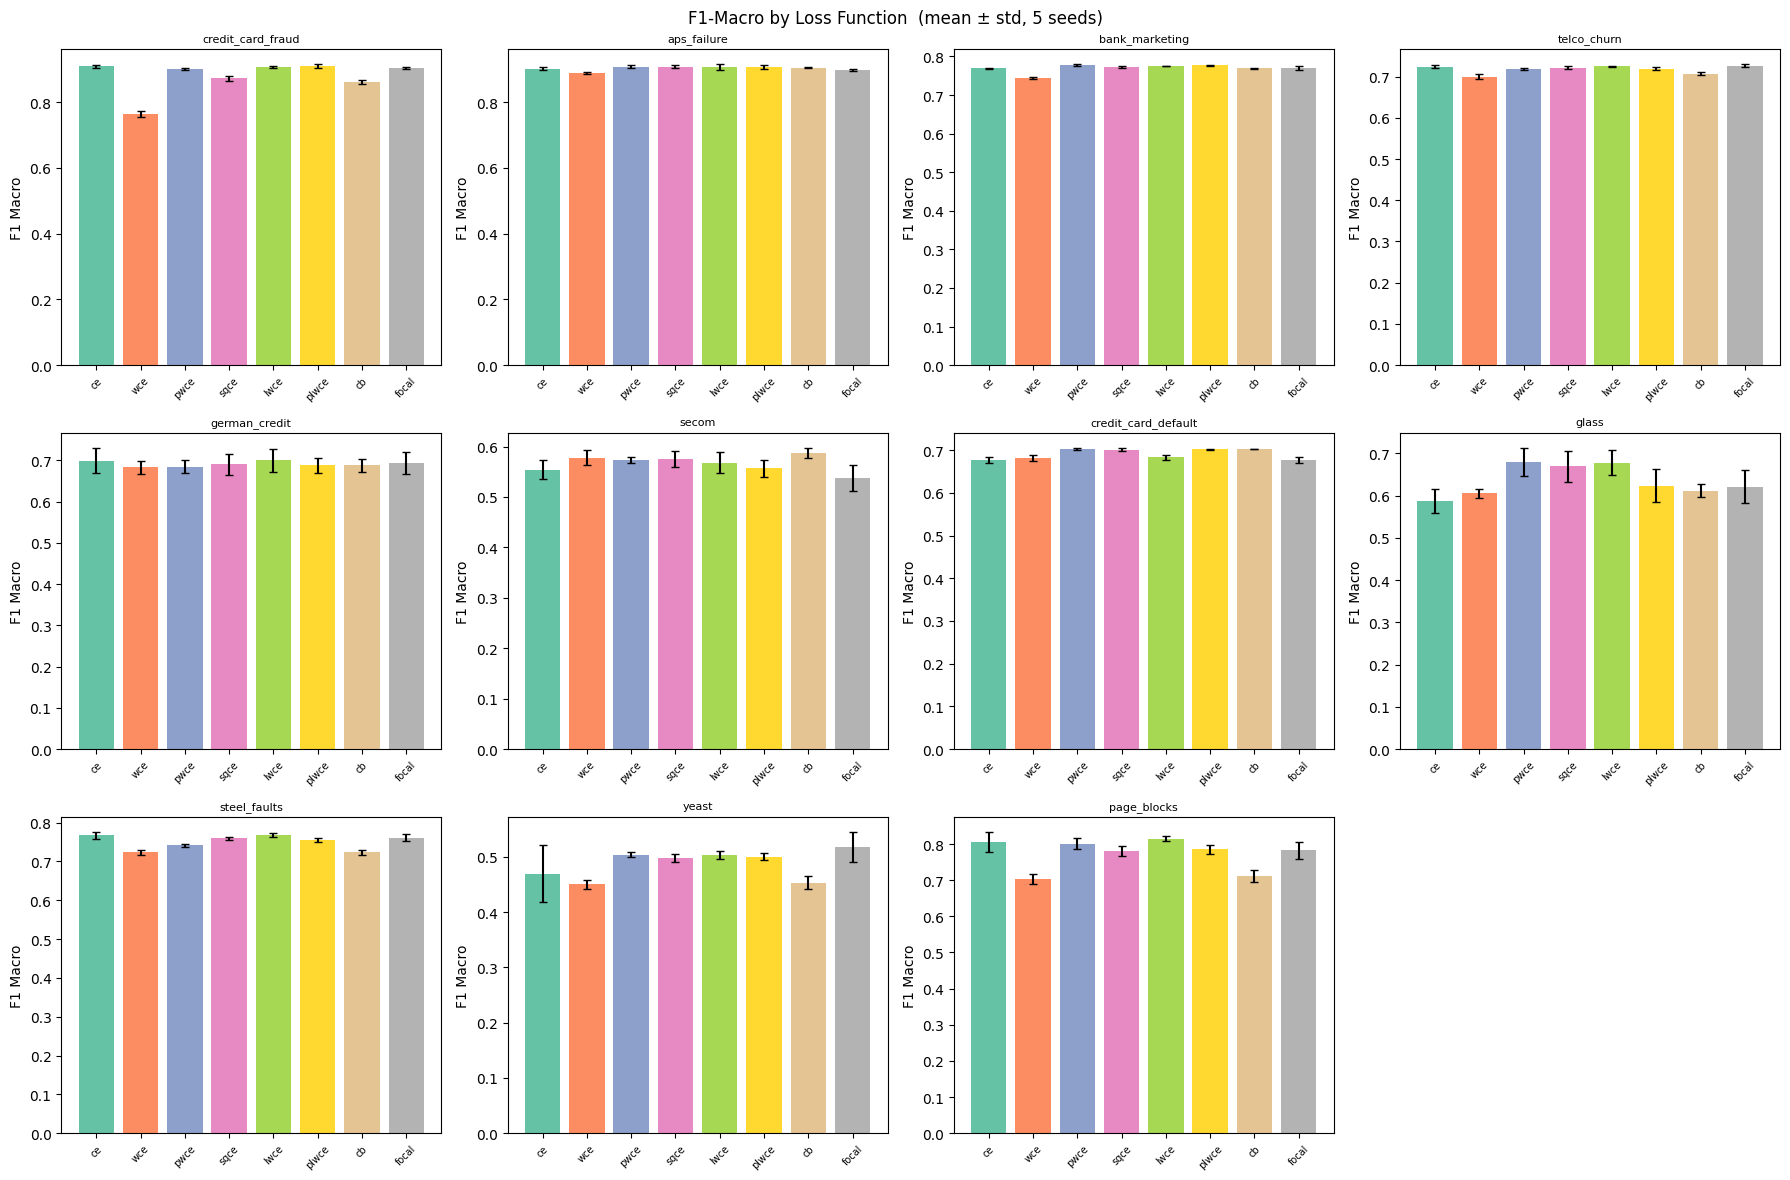

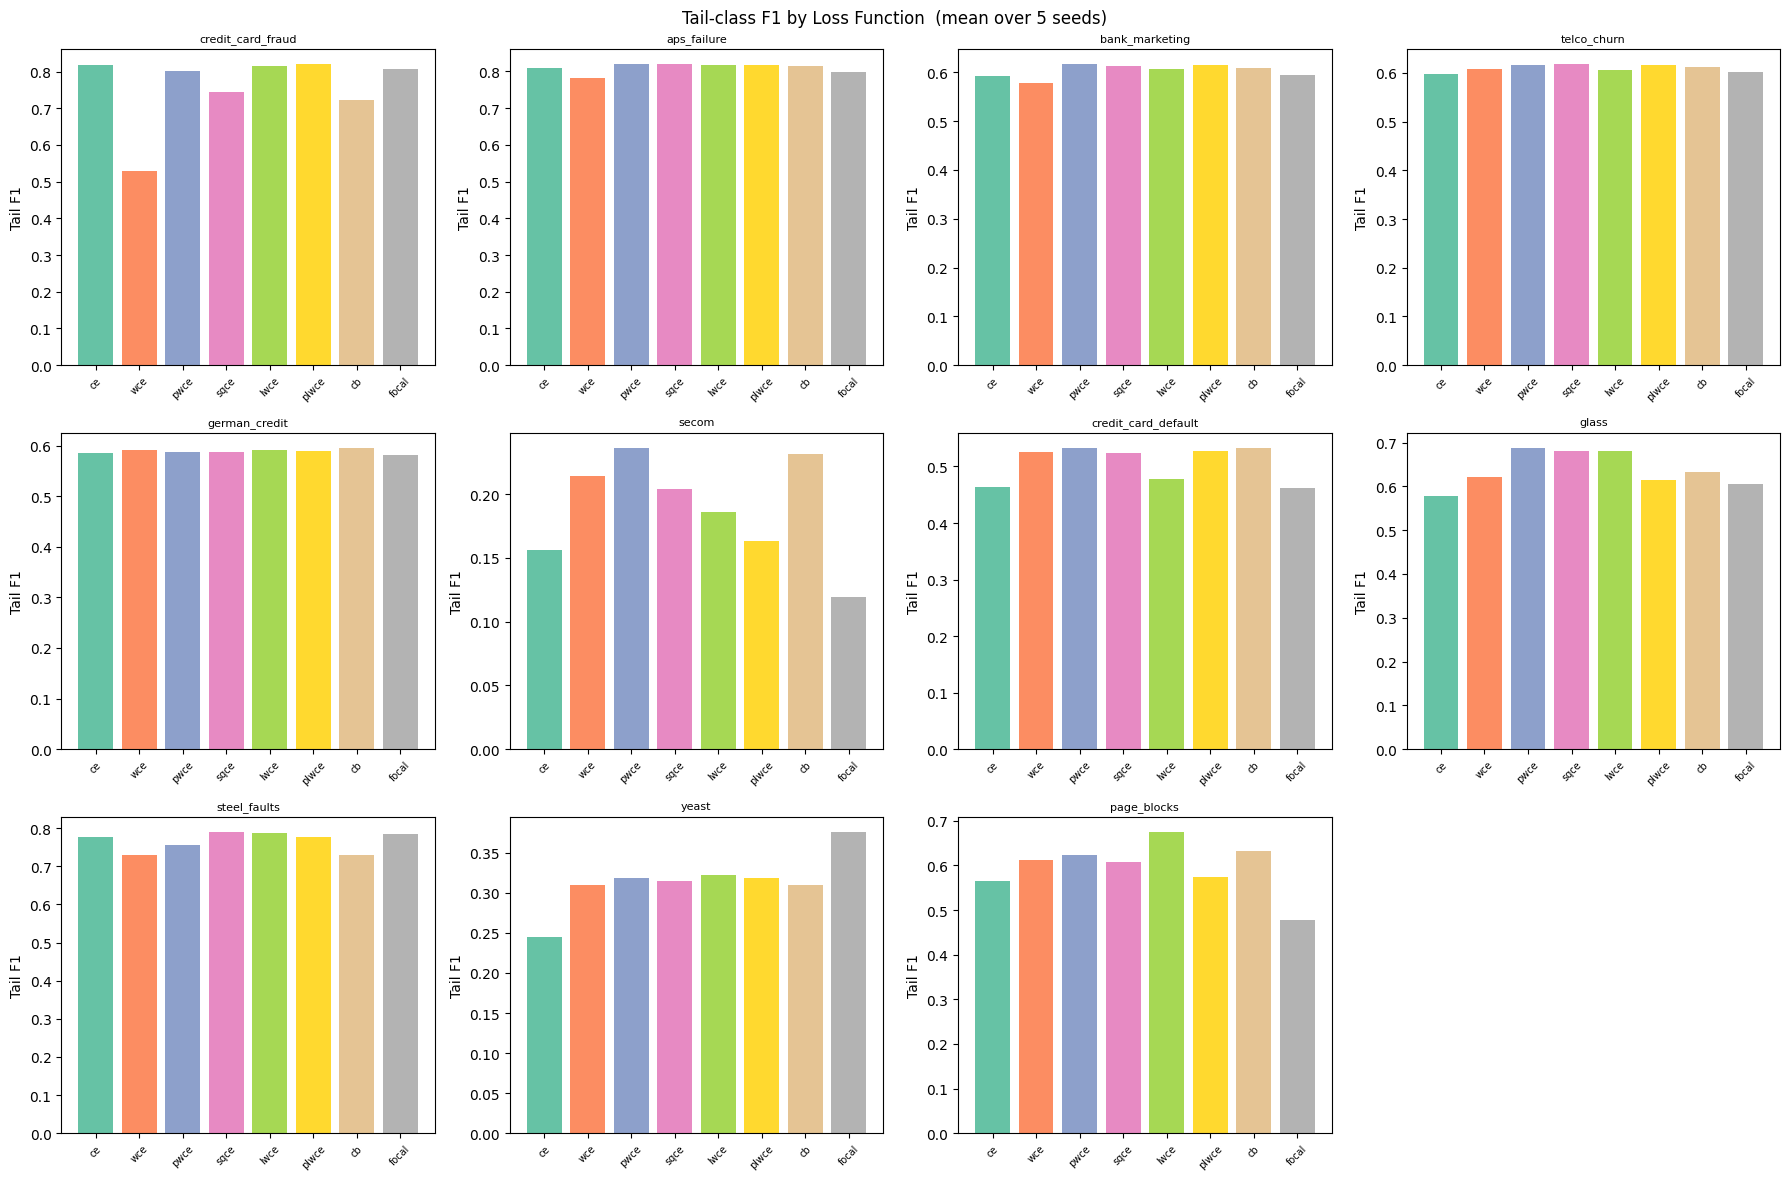

Loss                    ce    wce   pwce   sqce   lwce  plwce     cb  focal
Dataset                                                                    
aps_failure         0.9025 0.8887 0.9076 0.9075 0.9062 0.9063 0.9048 0.8974
bank_marketing      0.7689 0.7442 0.7778 0.7727 0.7753 0.7767 0.7695 0.7704
credit_card_default 0.6764 0.6811 0.7026 0.7010 0.6829 0.7017 0.7027 0.6762
credit_card_fraud   0.9088 0.7634 0.9010 0.8723 0.9075 0.9097 0.8615 0.9039
german_credit       0.6984 0.6834 0.6848 0.6900 0.6994 0.6875 0.6876 0.6928
glass               0.5868 0.6050 0.6794 0.6688 0.6775 0.6227 0.6115 0.6211
page_blocks         0.8050 0.7028 0.8006 0.7808 0.8142 0.7860 0.7115 0.7822
secom               0.5544 0.5780 0.5727 0.5754 0.5676 0.5567 0.5867 0.5374
steel_faults        0.7671 0.7233 0.7413 0.7600 0.7684 0.7556 0.7236 0.7615
telco_churn         0.7234 0.6997 0.7177 0.7218 0.7246 0.7187 0.7068 0.7264
yeast               0.4694 0.4503 0.5035 0.4981 0.5031 0.5006 0.4531 0.5174

Saved: /con

In [7]:
# Cell 7: Visualization + save
results_df = pd.DataFrame(all_results)

agg = results_df.groupby(['Dataset', 'Loss']).agg(
    F1_Macro_mean        =('F1_Macro',          'mean'),
    F1_Macro_std         =('F1_Macro',          'std'),
    Balanced_Acc_mean    =('Balanced_Accuracy', 'mean'),
    Tail_F1_mean         =('Tail_F1',           'mean'),
    Head_F1_mean         =('Head_F1',           'mean'),
    F1_Weighted_mean     =('F1_Weighted',       'mean'),
).reset_index()

colors = plt.cm.Set2(np.linspace(0, 1, len(LOSS_CONFIGS)))

# F1-Macro comparison
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, ds in enumerate(DATASETS):
    ax  = axes[idx]
    sub = agg[agg['Dataset'] == ds].set_index('Loss')
    means = [sub.loc[l, 'F1_Macro_mean'] if l in sub.index else 0 for l in LOSS_CONFIGS]
    stds  = [sub.loc[l, 'F1_Macro_std']  if l in sub.index else 0 for l in LOSS_CONFIGS]
    ax.bar(LOSS_CONFIGS, means, yerr=stds, color=colors, capsize=3)
    ax.set_title(ds, fontsize=8)
    ax.set_ylabel('F1 Macro')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)
plt.suptitle('F1-Macro by Loss Function  (mean \u00b1 std, 5 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/f1_macro_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Tail-F1 comparison
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, ds in enumerate(DATASETS):
    ax  = axes[idx]
    sub = agg[agg['Dataset'] == ds].set_index('Loss')
    vals = [sub.loc[l, 'Tail_F1_mean'] if l in sub.index else 0 for l in LOSS_CONFIGS]
    ax.bar(LOSS_CONFIGS, vals, color=colors)
    ax.set_title(ds, fontsize=8)
    ax.set_ylabel('Tail F1')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)
plt.suptitle('Tail-class F1 by Loss Function  (mean over 5 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/tail_f1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary pivot table
pivot = agg.pivot_table(index='Dataset', columns='Loss', values='F1_Macro_mean')
print(pivot[LOSS_CONFIGS].to_string(float_format='{:.4f}'.format))

# Save Excel
excel_path = f'{RESULTS_DIR}/mlp_results.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    agg.to_excel(writer, sheet_name='Summary', index=False)
    results_df.to_excel(writer, sheet_name='All_Runs', index=False)
    # best_params는 {ds: {loss: {param: v}}} 중첩 → 평탄화해서 저장
    bp_rows = [{'Dataset': d, 'Loss': l, **prm}
               for d, lp in best_params.items() for l, prm in lp.items()]
    pd.DataFrame(bp_rows).to_excel(writer, sheet_name='Best_Params', index=False)

# Save combined JSON
with open(f'{RESULTS_DIR}/mlp_all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\nSaved: {excel_path}')
print(f'Saved: {RESULTS_DIR}/mlp_all_results.json')

In [ ]:
# === Cell 8: 3차 피드백 §4.5~4.7 분석 (mechanism / sensitivity / ablation) ===
# 통계검정(Friedman/Holm)은 '데이터셋을 블록'으로 두는 것이 정석이므로
# 전 도메인 결과가 모인 뒤 통합 스크립트에서 수행한다 (여기서는 생략).
from itertools import cycle

ANALYSIS_DIR = f'{RESULTS_DIR}/analysis'
os.makedirs(ANALYSIS_DIR, exist_ok=True)
colors_loss = plt.cm.tab20(np.linspace(0, 1, len(LOSS_CONFIGS)))

# class_counts는 학습 루프에서 저장해 둔 것을 읽는다.
# (network은 메모리 절약차 데이터셋마다 del 하므로 메모리에 남아있지 않음)
with open(COUNTS_PATH) as f:
    raw_counts = json.load(f)
ds_list = [d for d in DATASETS if d in all_histories and d in raw_counts]

# ── (1) §4.7 Optimization Stability — 데이터셋별 Gradient Norm & Few/Many Ratio ──
# "성능 향상만으로는 Weight Explosion 완화를 증명 못 한다"는 지적에 대한 직접 증거.
for key, ylab, logy in [('grad_norm', 'Gradient Norm (log)', True),
                        ('grad_ratio', 'Few/Many Gradient Ratio (log)', True),
                        ('train_loss', 'Train Loss', False)]:
    ncol = 4
    nrow = int(np.ceil(len(ds_list) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.4 * nrow))
    axes = np.atleast_1d(axes).flatten()
    for i, ds in enumerate(ds_list):
        ax = axes[i]
        for l_idx, loss_name in enumerate(LOSS_CONFIGS):
            hs = [all_histories[ds][f'{loss_name}_s{s}'] for s in SEEDS
                  if f'{loss_name}_s{s}' in all_histories[ds]]
            if not hs or key not in hs[0]:
                continue
            arr = np.array([h[key] for h in hs], dtype=float)
            mean = np.nanmean(arr, 0)
            ax.plot(np.arange(len(mean)), mean, label=loss_name,
                    color=colors_loss[l_idx], alpha=0.85, linewidth=1.1)
        if logy:
            ax.set_yscale('log')
        if key == 'grad_ratio':
            ax.axhline(1.0, color='k', linestyle=':', linewidth=1, alpha=0.6)
        ax.set_title(ds, fontsize=8); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    for j in range(len(ds_list), len(axes)):
        axes[j].set_visible(False)
    axes[0].set_ylabel(ylab); axes[0].legend(fontsize=6, ncol=2)
    plt.suptitle(ylab, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/stability_{key}.png', dpi=130, bbox_inches='tight')
    plt.close()

print('■ Gradient 통계 (마지막 epoch, seed 평균)')
print(f'{"Dataset":22s} | {"Loss":10s} | {"grad_norm":>10} | {"Few/Many":>9}')
print('-' * 60)
grad_summary = {}
for ds in ds_list:
    for loss_name in LOSS_CONFIGS:
        hs = [all_histories[ds][f'{loss_name}_s{s}'] for s in SEEDS
              if f'{loss_name}_s{s}' in all_histories[ds]]
        if not hs or 'grad_norm' not in hs[0]:
            continue
        gn = float(np.mean([h['grad_norm'][-1] for h in hs]))
        gr = float(np.nanmean([h['grad_ratio'][-1] for h in hs]))
        grad_summary[f'{ds}_{loss_name}'] = {'grad_norm_final': gn, 'grad_ratio_final': gr}
        print(f'{ds:22s} | {loss_name:10s} | {gn:10.4f} | {gr:9.3f}')

# ── (2) §4.7 Class Weight Distribution + Proposition 3 검증 ──
print('\n■ 가중치 동적 범위 w_rare/w_freq — Proposition 3')
print(f'{"Dataset":22s} | {"IR":>8} | {"Loss":10s} | {"w_rare/w_freq":>14} | 이론')
print('-' * 78)
THEORY = {'wce': 'rho', 'pwce': 'rho^alpha', 'sqce': 'sqrt(rho)',
          'lwce': 'O(log rho)', 'plwce': 'O((log rho)^alpha)',
          'eslwce': '<= LWCE', 'combined': 'O((log rho)^alpha)', 'cb': '-'}
ncol = 4
nrow = int(np.ceil(len(ds_list) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.4 * nrow))
axes = np.atleast_1d(axes).flatten()
weight_rows = []
for i, ds in enumerate(ds_list):
    cc = raw_counts[ds]
    order = np.argsort(np.array(cc))[::-1]
    ir = max(cc) / max(1, min(cc))
    ax = axes[i]
    markers = cycle(['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<', '>', 'h'])
    for l_idx, loss_name in enumerate(LOSS_CONFIGS):
        # 파라미터는 Optuna 최적값 기준 — metrics에 저장된 값을 그대로 사용
        row = next((r for r in all_results if r['Dataset'] == ds and r['Loss'] == loss_name), None)
        if row is None:
            continue
        kw = {k: row[k] for k in ('alpha', 'gamma', 'eps', 'tau') if k in row}
        w = get_clf_loss(loss_name, cc, **kw).get_weights()
        w_plot = np.ones(len(cc)) if w is None else w      # None = 균일(ce/focal/logitadj)
        ax.plot(range(len(cc)), w_plot[order], marker=next(markers), markersize=2.5,
                label=loss_name, color=colors_loss[l_idx], alpha=0.85, linewidth=1.1)
        if w is not None:
            ratio = w[order[-1]] / w[order[0]]
            print(f'{ds:22s} | {ir:8.1f} | {loss_name:10s} | {ratio:14.2f} | '
                  f'{THEORY.get(loss_name, "-")}')
            weight_rows.append({'Dataset': ds, 'IR': float(ir), 'Loss': loss_name,
                                'w_rare_over_w_freq': float(ratio)})
    ax.set_yscale('log')
    ax.set_title(f'{ds} (IR={ir:.0f})', fontsize=8)
    ax.set_xlabel('Class (many → few)'); ax.grid(alpha=0.3)
for j in range(len(ds_list), len(axes)):
    axes[j].set_visible(False)
axes[0].set_ylabel('Normalized weight (log)'); axes[0].legend(fontsize=6, ncol=2)
plt.suptitle(r'Class Weight Distribution  $\tilde{w}_c = C w_c / \sum_j w_j$', fontsize=12)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}/class_weight_distribution.png', dpi=130, bbox_inches='tight')
plt.close()

# ── (3) §4.6 Sensitivity (Optuna trial 재활용 — 추가 학습 없음) ──
if os.path.exists(TRIALS_PATH):
    with open(TRIALS_PATH) as f:
        trials_data = json.load(f)
    ONE_D = [('pwce', 'alpha'), ('plwce', 'alpha'), ('eslwce', 'eps'),
             ('focal', 'gamma'), ('logitadj', 'tau')]
    fig, axes = plt.subplots(len(ds_list), len(ONE_D),
                             figsize=(3.6 * len(ONE_D), 2.8 * len(ds_list)))
    axes = np.atleast_2d(axes)
    for r, ds in enumerate(ds_list):
        for c, (loss_name, param) in enumerate(ONE_D):
            ax = axes[r][c]
            ts = trials_data.get(ds, {}).get(loss_name)
            if not ts:
                ax.set_visible(False); continue
            ts = sorted(ts, key=lambda t: t['params'][param])
            ax.plot([t['params'][param] for t in ts], [t['value'] for t in ts],
                    marker='o', markersize=2, color='#2d4860', linewidth=1)
            best = max(ts, key=lambda t: t['value'])
            ax.axvline(best['params'][param], color='#e74c3c', linestyle='--', linewidth=1)
            if param == 'eps':
                ax.set_xscale('log')
            ax.set_title(f'{ds[:14]} · {loss_name}', fontsize=7)
            ax.set_xlabel(param, fontsize=7); ax.grid(alpha=0.3)
            ax.tick_params(labelsize=6)
    plt.suptitle('Sensitivity (proxy val F1-Macro)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/sensitivity_1d.png', dpi=130, bbox_inches='tight')
    plt.close()
    print('\n✓ sensitivity_1d.png (proxy 기준 — 논문 그림엔 full-training sweep 권장)')

# ── (4) §4.5 Ablation 표 ──
print('\n■ Ablation (3차 피드백 §4.5)  [Log compression / Power α / Smoothing ε]')
print(f'{"Dataset":22s} | {"Method":10s} | {"LC":^3} | {"α":^3} | {"ε":^3} | '
      f'{"F1-Macro":^15} | {"Worst":^6} | {"G-Mean":^6}')
print('-' * 90)
ablation_rows = []
for ds in ds_list:
    for name, lc, pw, sm in ABLATION_ROWS:
        rs = [r for r in all_results if r['Dataset'] == ds and r['Loss'] == name]
        if not rs:
            continue
        f1 = [r['F1_Macro'] for r in rs]
        wo = float(np.mean([r.get('Worst_Acc', 0) for r in rs]))
        gm = float(np.mean([r.get('G_Mean', 0) for r in rs]))
        print(f'{ds:22s} | {name:10s} | {lc:^3} | {pw:^3} | {sm:^3} | '
              f'{np.mean(f1):.4f}±{np.std(f1):.4f} | {wo:6.4f} | {gm:6.4f}')
        ablation_rows.append({'Dataset': ds, 'Method': name, 'LogCompression': lc,
                              'Power_alpha': pw, 'Smoothing_eps': sm,
                              'F1_Macro_mean': float(np.mean(f1)),
                              'F1_Macro_std': float(np.std(f1)),
                              'Worst_Acc': wo, 'G_Mean': gm})

with open(f'{ANALYSIS_DIR}/analysis_summary.json', 'w') as f:
    json.dump({'grad_summary': grad_summary, 'ablation': ablation_rows,
               'weight_ratios': weight_rows}, f, indent=2)
print(f'\n✓ 분석 저장 → {ANALYSIS_DIR}/')
print('  PNG: stability_grad_norm / stability_grad_ratio / stability_train_loss / '
      'class_weight_distribution / sensitivity_1d')
